CREDIT CARD FRAUD DETECTION PROJECT

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib
from google.colab import files

In [ ]:
print("Loading dataset...")
df = pd.read_csv('/content/sample_data/dataset.csv')
print("Dataset shape:", df.shape) #Shows number of rows and columns
df.head()

Loading dataset...
Dataset shape: (105015, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


DATA PREPROCESSING & CLEANING

In [ ]:
# Convert transaction date(string) to datetime(format)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract temporal features
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month


In [ ]:
# Drop irrelevant columns
drop_columns = ['Unnamed: 0','trans_date_trans_time', 'first','last','street','state','zip','dob','job','trans_num']
df = df.drop(columns=drop_columns)

In [ ]:
print("Data after cleaning:", df.shape)
df.head()

Data after cleaning: (105015, 16)


,cc_num,merchant,category,amt,gender,city,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,36.0788,-81.1781,3495,1.325376e+09,36.011293,-82.048315,0.0,0,1,1
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,48.8878,-118.2105,149,1.325376e+09,49.159047,-118.186462,0.0,0,1,1
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,42.1808,-112.2620,4154,1.325376e+09,43.150704,-112.154481,0.0,0,1,1
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,46.2306,-112.1138,1939,1.325376e+09,47.034331,-112.561071,0.0,0,1,1
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,38.4207,-79.4629,99,1.325376e+09,38.674999,-78.632459,0.0,0,1,1


Heatmap of Fraud Density

In [ ]:
from folium.plugins import HeatMap

fraud_locations = df[df['is_fraud'] == 1][['lat', 'long']]

m_heat = folium.Map(
    location=[fraud_locations['lat'].mean(), fraud_locations['long'].mean()],
    zoom_start=5
)

HeatMap(fraud_locations.values, radius=10).add_to(m_heat)

m_heat


EXPLORATORY DATA ANALYSIS (EDA)

/tmp/ipython-input-3646161042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='coolwarm')


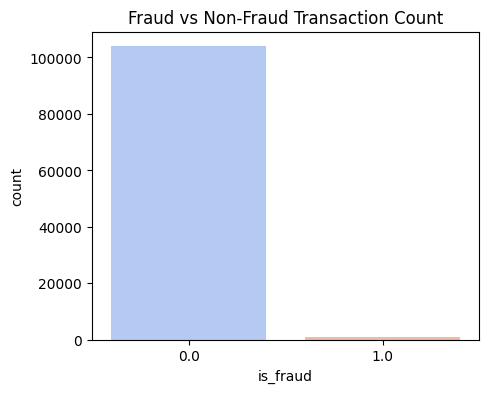

Fraudulent transactions: 0.98%


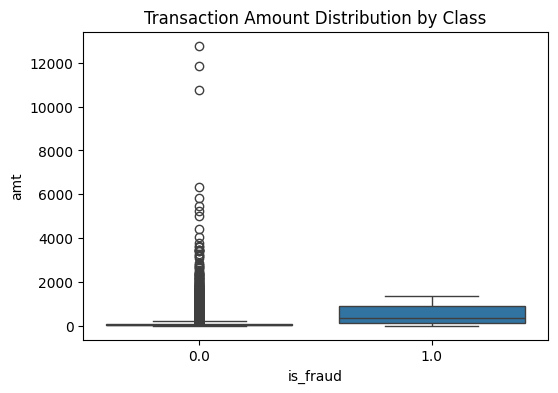

In [ ]:
# Fraud class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='is_fraud', data=df, palette='coolwarm')
plt.title('Fraud vs Non-Fraud Transaction Count')
plt.show()

fraud_percent = df['is_fraud'].mean() * 100
print(f"Fraudulent transactions: {fraud_percent:.2f}%")

# Amount distribution
plt.figure(figsize=(6,4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Transaction Amount Distribution by Class')
plt.show()

In [ ]:
# Encode categorical columns
cat_col = ['merchant','category','gender']
encoders ={}
for col in cat_col:
  encoders[col]=LabelEncoder()
  df[col]=encoders[col].fit_transform(df[col])

[ pip install pandas numpy lightgbm seaborn matplotlib scikit-learn imblearn geopy joblib streamlit ]

In [ ]:
# ========== 5️⃣ TRAIN-TEST SPLIT ==========
df = df.dropna(subset=['is_fraud'])

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (78760, 15)
Test shape: (26254, 15)


In [ ]:
df = df.dropna(subset=['lat', 'long', 'merch_lat', 'merch_long'])

def haversine(lat1, lon1, lat2, lon2):
    return np.array([geodesic((a, b), (c, d)).km for a, b, c, d in zip(lat1, lon1, lat2, lon2)])

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [ ]:
df.head()

,cc_num,merchant,category,amt,gender,city,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,2703186189652095,514,8,4.97,0,Moravian Falls,36.0788,-81.1781,3495,1.325376e+09,36.011293,-82.048315,0.0,0,1,1,78.773821
1,630423337322,241,4,107.23,0,Orient,48.8878,-118.2105,149,1.325376e+09,49.159047,-118.186462,0.0,0,1,1,30.216618
2,38859492057661,390,0,220.11,1,Malad City,42.1808,-112.2620,4154,1.325376e+09,43.150704,-112.154481,0.0,0,1,1,108.102912
3,3534093764340240,360,2,45.00,1,Boulder,46.2306,-112.1138,1939,1.325376e+09,47.034331,-112.561071,0.0,0,1,1,95.685115
4,375534208663984,297,9,41.96,1,Doe Hill,38.4207,-79.4629,99,1.325376e+09,38.674999,-78.632459,0.0,0,1,1,77.702395


In [ ]:
features = ['merchant', 'category', 'amt', 'cc_num', 'hour', 'day', 'month','gender', 'distance']
x = df[features]
y = df['is_fraud']

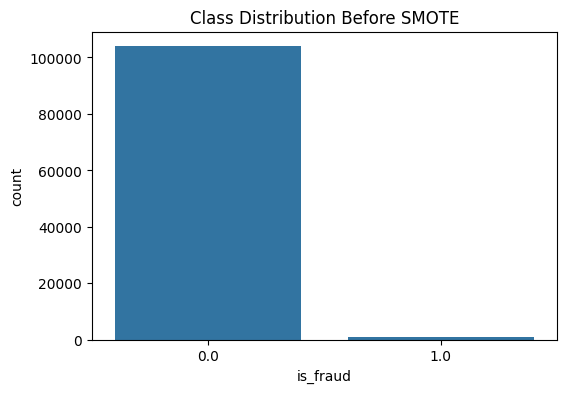

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df)
plt.title('Class Distribution Before SMOTE')
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
x_resample, y_resample = smote.fit_resample(x, y)

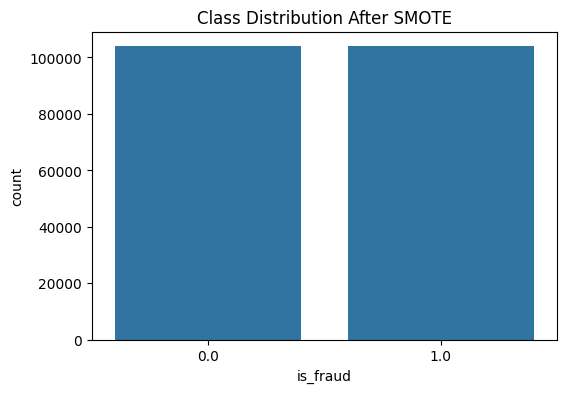

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resample)
plt.title('Class Distribution After SMOTE')
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2, random_state=42)

Plot fraud vs non-fraud transactions on a real map using latitude & longitude.

In [ ]:
import folium

# Sample few fraud cases for visualization
fraud_samples = df[df['is_fraud'] == 1].sample(200, random_state=42)

# Create base map
m = folium.Map(
    location=[fraud_samples['lat'].mean(), fraud_samples['long'].mean()],
    zoom_start=5
)

# Plot fraud transactions
for _, row in fraud_samples.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=f"Amount: {row['amt']}"
    ).add_to(m)

m


Feature Scaling for Monetary Values - Transaction amount varies hugely → scaling helps stability.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_res['amt'] = scaler.fit_transform(X_train_res[['amt']])
X_test['amt'] = scaler.transform(X_test[['amt']])


MODEL TRAINING (LightGBM)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    is_unbalance=True,
    num_leaves=31,
    learning_rate=0.05,
    max_depth=1,
    n_estimators=200
)
lgb_model.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 83195, number of negative: 83179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1096
[LightGBM] [Info] Number of data points in the train set: 166374, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500048 -> initscore=0.000192
[LightGBM] [Info] Start training from score 0.000192
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=1, metric='auc',
               n_estimators=200, objective='binary')

Model Explainability with SHAP - Shows WHY a transaction is fraud

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


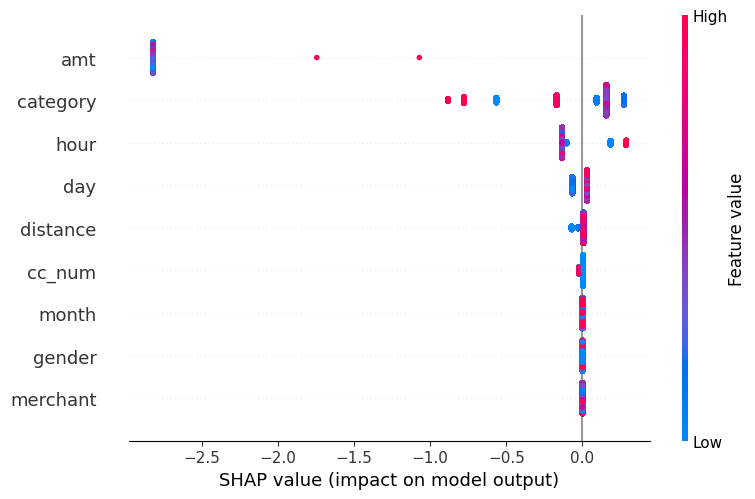

In [ ]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Optimal Threshold Tuning -
Fraud detection prioritizes Recall over Accuracy
(Default threshold = 0.5 is not optimal)

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold with best F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

# Apply new threshold
y_pred_custom = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


Best Threshold: 0.9298950187074045
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     20797
         1.0       0.55      0.59      0.57       206

    accuracy                           0.99     21003
   macro avg       0.77      0.79      0.78     21003
weighted avg       0.99      0.99      0.99     21003



In [ ]:
y_pred = lgb_model.predict(x_test)

In [ ]:
print("Classification_Report:\n", classification_report(y_test,y_pred))
print("Roc AUC Score: ", roc_auc_score(y_test, y_pred))

Classification_Report:
               precision    recall  f1-score   support

         0.0       0.81      0.96      0.88     20805
         1.0       0.95      0.77      0.85     20789

    accuracy                           0.86     41594
   macro avg       0.88      0.86      0.86     41594
weighted avg       0.88      0.86      0.86     41594

Roc AUC Score:  0.8638871478130551


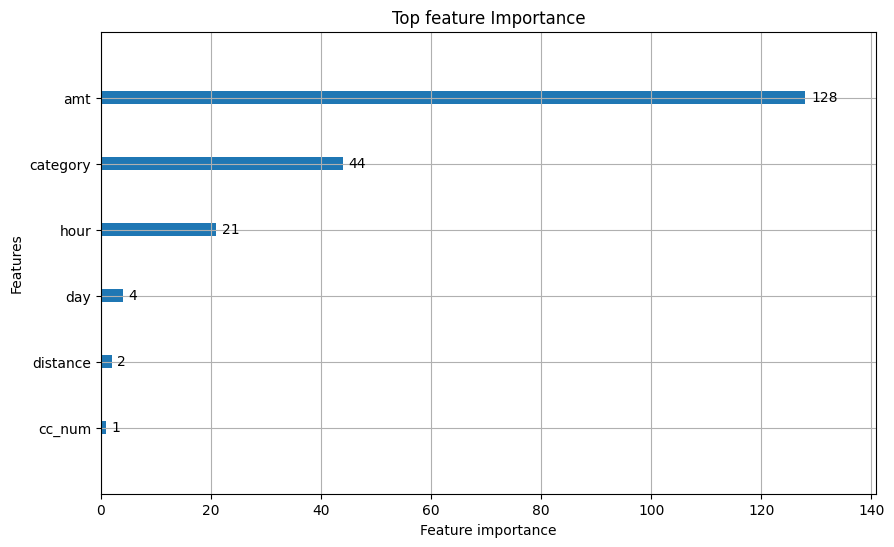

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split', figsize=(10, 6))
plt.title("Top feature Importance")
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, lgb_model.predict_proba(x_test)[:,1])
roc_auc = auc(fpr,tpr)

In [ ]:
y_prob = lgb_model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("Improved ROC-AUC:", roc_auc)


Improved ROC-AUC: 0.9484876049831735


Confusion Matrix Visualization - Confusion Matrix Visualization

Shape of y_test: (41594,)
Shape of y_pred: (41594,)


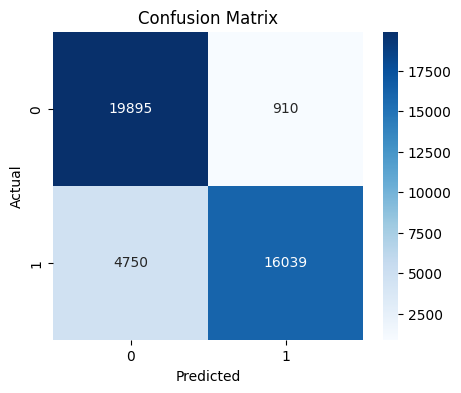

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Re-split the SMOTE data to ensure y_test is consistent with x_test and y_pred
# This ensures y_test has the correct number of samples (41594) to match y_pred
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2, random_state=42)

# Ensure y_pred is calculated with the correct x_test if it hasn't been already
y_pred = lgb_model.predict(x_test)

print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_pred: {y_pred.shape}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(lgb_model, "fraud_detection_model.jb")
joblib.dump(encoders, "label_encoder.jb")

['label_encoder.jb']

In [ ]:
df[df['is_fraud']==1].head()

,cc_num,merchant,category,amt,gender,city,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
2449,4613314721966,543,4,281.06,1,Collettsville,35.9946,-81.7266,885,1.325466e+09,36.430124,-81.179483,1.0,1,2,1,68.962726
2472,340187018810220,285,2,11.52,0,San Antonio,29.4400,-98.4590,1595797,1.325469e+09,29.819364,-99.142791,1.0,1,2,1,78.443229
2523,340187018810220,196,4,276.31,0,San Antonio,29.4400,-98.4590,1595797,1.325474e+09,29.273085,-98.836360,1.0,3,2,1,41.048425
2546,4613314721966,162,2,7.03,1,Collettsville,35.9946,-81.7266,885,1.325475e+09,35.909292,-82.091010,1.0,3,2,1,34.211963
2553,340187018810220,328,4,275.73,0,San Antonio,29.4400,-98.4590,1595797,1.325477e+09,29.786426,-98.683410,1.0,3,2,1,44.124854


Draw lines from customer location to merchant location for fraud cases - Shows long-distance suspicious transactions visually.

In [ ]:
fraud_flow = df[df['is_fraud'] == 1].sample(100, random_state=42)

m_flow = folium.Map(
    location=[fraud_flow['lat'].mean(), fraud_flow['long'].mean()],
    zoom_start=4
)

for _, row in fraud_flow.iterrows():
    folium.PolyLine(
        locations=[
            (row['lat'], row['long']),
            (row['merch_lat'], row['merch_long'])
        ],
        color="red",
        weight=2,
        opacity=0.6
    ).add_to(m_flow)

m_flow


Fraud by Distance Bucket

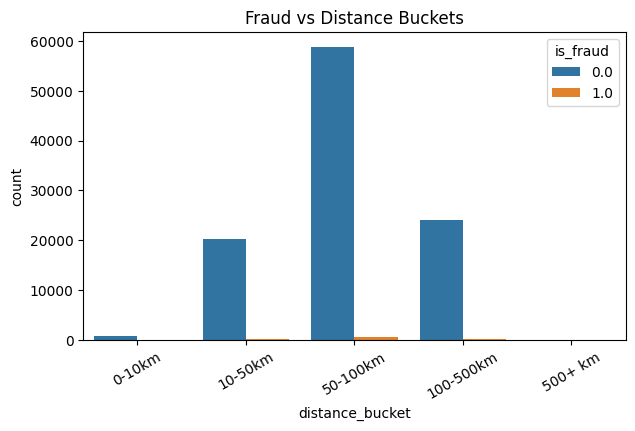

In [ ]:
df['distance_bucket'] = pd.cut(
    df['distance'],
    bins=[0,10,50,100,500,10000],
    labels=['0-10km','10-50km','50-100km','100-500km','500+ km']
)

plt.figure(figsize=(7,4))
sns.countplot(x='distance_bucket', hue='is_fraud', data=df)
plt.xticks(rotation=30)
plt.title("Fraud vs Distance Buckets")
plt.show()


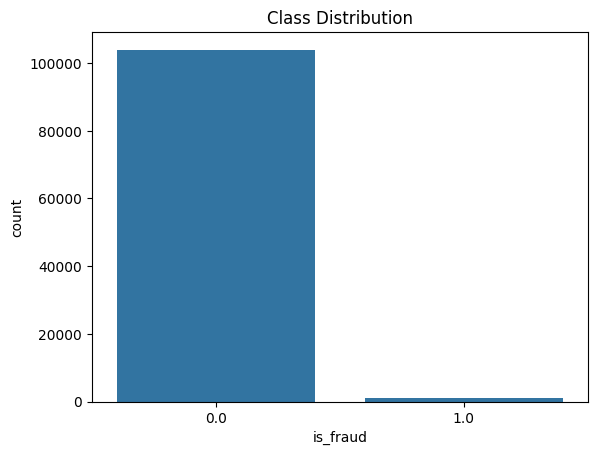

In [ ]:
sns.countplot(x='is_fraud', data=df)
plt.title('Class Distribution')
plt.show()

In [ ]:
joblib.dump(lgb_model, "fraud_detection_model.joblib")
joblib.dump(encoders, "label_encoder.joblib")


['label_encoder.joblib']

In [ ]:
from google.colab import files
files.download("fraud_detection_model.joblib")
files.download("label_encoder.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Time vs Fraud Visualization

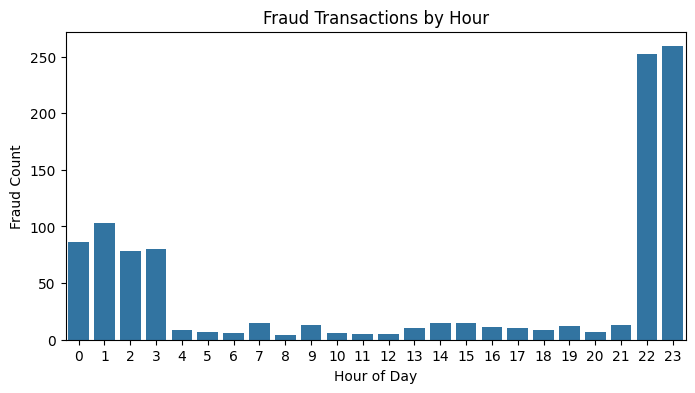

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='hour', data=df[df['is_fraud'] == 1])
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()


Combine ML Prediction + Map - Show predicted frauds on map

In [ ]:
predicted_fraud = X_test.copy()
predicted_fraud['prediction'] = y_pred_custom
predicted_fraud['lat'] = df.loc[X_test.index, 'lat']
predicted_fraud['long'] = df.loc[X_test.index, 'long']

fraud_pred_map = predicted_fraud[predicted_fraud['prediction'] == 1].sample(150)

m_pred = folium.Map(
    location=[fraud_pred_map['lat'].mean(), fraud_pred_map['long'].mean()],
    zoom_start=5
)

for _, row in fraud_pred_map.iterrows():
    folium.CircleMarker(
        [row['lat'], row['long']],
        radius=4,
        color='orange',
        fill=True
    ).add_to(m_pred)

m_pred


Model Summary:
- Algorithm: LightGBM
- Metrics: ROC-AUC, Precision, Recall, F1-Score
- Handling Imbalance: SMOTE
- Feature Importance: Transaction Amount, Category, Distance, etc.

Insights:
1. Only a small fraction of transactions are fraudulent.
2. Transaction amount and distance play a significant role in detection.
3. LightGBM achieved strong performance on test data.
4. Encoders and model are exported for real-time Streamlit deployment.

